# $\sigma_{PS}$ condensate vs mass, all Nf (gsq=8, nt128 L2)

Reads `h0/condensate/etadag_xi` from the massive Real-$m$ disc data
(`data_Nf{nf}_..._mRe{m}..._vmRe{m}.../corr_ylm_disc_tb2_nhits1/`).
Convention = per-mass notebook's $\sigma_{PS}$ cell: $\mathrm{dens}=\mathrm{etadag\_xi}/(N_t\cdot 4\pi)$,
$\sigma_{PS}=\mathrm{dens}+\overline{\mathrm{dens}}$; **contact-subtracted $+2$**
(`condensate_contact_massive_claude.md` Sec 10, mass-independent) = SSB order parameter.
Config-jackknife (1 hit/config).  **x-axis = effective $m_F$ at L2 = physical bare mass $\times 0.506305$**
(L2 measure factor `mean_dual_area/mean_ell`, `heavy_mass_L124_impl_plan_claude.md`), the **same
convention for light and heavy**.  Light dirs mRe0.211450.. (physical), Nf=2,4,6 $\to m_F\approx0.107,0.054,0.027,0.0054$;
**heavy** $m_F=0.2141,0.4282,0.6423$ (Nf=2 only, red diamond).  Plot is log-log to expose the linear $\sigma_{PS}\sim\chi\,m_F$ approach to zero.


In [1]:
import h5py, numpy as np, glob, math
import matplotlib.pyplot as plt

Nt = 128
sumA = 4.0*math.pi
norm = Nt*sumA
# x-axis = EFFECTIVE m_F at L2 = physical bare mass x 0.506305 (L2 measure factor
# mean_dual_area/mean_ell, heavy_mass_L124_impl_plan_claude.md).  SAME convention as the heavy
# points.  Previously light used the L1 factor 0.9459 (mislabeled as 0.2/0.1/0.05/0.01), so light
# and heavy sat on different conventions and their slopes were not comparable.  MASS_DIR strings =
# the input mRe dir names = physical bare mass (sea = valence).
MEAS_L2 = 0.506305                                            # L2 measure factor (mean_dual_area/mean_ell)
MASS_DIR = ['0.211450', '0.105725', '0.052862', '0.010572']   # dir string = physical bare mass
MASS = np.array([float(m) for m in MASS_DIR])*MEAS_L2         # effective m_F at L2 (x-axis); matches heavy
NFS = [2, 4, 6]
NFMARK = ['o', 's', '^']                                      # colorblind: distinct marker per Nf

def esn(nf, m): return f'data_Nf{nf}_gsq8.000000at0.200000nu01.000000mRe{m}mIm0.000000nt128L2_vmRe{m}vmIm0.000000/'
def disc_files(nf, m): return sorted(glob.glob(esn(nf, m)+'corr_ylm_disc_tb2_nhits1/corr.*.h0.h5'))

def cond_cfg(files):
    out = []
    for fn in files:
        with h5py.File(fn, 'r') as f:
            out.append(f['h0/condensate/etadag_xi/real'][0] + 1j*f['h0/condensate/etadag_xi/imag'][0])
    return np.array(out)

def jackknife(samp):                  # delete-1 over config axis -> mean, err_re, err_im
    H = samp.shape[0]
    jk = (samp.sum(0)-samp)/(H-1)
    mean = samp.mean(0)
    ere = np.sqrt(np.maximum((H-1)*np.mean((jk.real-mean.real)**2, 0), 0.0))
    eim = np.sqrt(np.maximum((H-1)*np.mean((jk.imag-mean.imag)**2, 0), 0.0))
    return mean, ere, eim

# sigma_PS per (Nf, mass): raw + contact-subtracted (+2), config-jackknifed.  SIG[nf] = (raw_m, raw_e, sub_m, sub_e)
SIG = {}
for nf in NFS:
    rm = []
    re = []
    sm = []
    se = []
    for md_ in MASS_DIR:
        df = disc_files(nf, md_)
        etx = cond_cfg(df)
        dens = etx/norm
        sig = dens + np.conj(dens)
        m0, e0, _ = jackknife(sig)
        m2, e2, _ = jackknife(sig + 2.0)
        rm.append(m0.real)
        re.append(e0)
        sm.append(m2.real)
        se.append(e2)
    SIG[nf] = (np.array(rm), np.array(re), np.array(sm), np.array(se))
    print(f'Nf={nf}: loaded {len(disc_files(nf, MASS_DIR[0]))} cfg/mass')


Nf=2: loaded 70 cfg/mass
Nf=4: loaded 70 cfg/mass
Nf=6: loaded 69 cfg/mass


In [2]:
# Heavy sea masses (Nf2 only): sigma_PS at effective m_F.  Same disc-byproduct condensate,
# contact-sub +2 (mass-independent; condensate_contact_massive_claude.md Sec 10).
# Defensive: skip masses not yet measured (empty / <2 cfg glob).  x-axis = effective m_F (L2).
HEAVY_DIR = ['0.422900', '0.845799', '1.268699']      # dir mRe string (valence = sea = physical m)
HEAVY_MF = [0.2141, 0.4282, 0.6423]                   # effective m_F at L2 (heavy_mass_L124_impl_plan)
hmf = []
hrm = []
hre = []
hsm = []
hse = []
for md_, mf in zip(HEAVY_DIR, HEAVY_MF):
    df = sorted(glob.glob(esn(2, md_) + 'corr_condensate_eo_nhits1/corr.*.h0.h5'))  # NEW dedicated condensate driver (was corr_ylm_disc_tb2)
    if len(df) < 2:
        print(f'heavy m_F={mf}: {len(df)} cfg -- skipped (not yet measured)')
        continue
    etx = cond_cfg(df)
    dens = etx/norm
    sig = dens + np.conj(dens)
    m0, e0, _ = jackknife(sig)
    m2, e2, _ = jackknife(sig + 2.0)
    hmf.append(mf)
    hrm.append(m0.real)
    hre.append(e0)
    hsm.append(m2.real)
    hse.append(e2)
    print(f'heavy m_F={mf}: {len(df)} cfg  sigma_PS(sub +2) = {m2.real:+.5f} +/- {e2:.1e}')
HEAVY = (np.array(hmf), np.array(hrm), np.array(hre), np.array(hsm), np.array(hse))


heavy m_F=0.2141: 70 cfg  sigma_PS(sub +2) = +0.17163 +/- 1.7e-05
heavy m_F=0.4282: 70 cfg  sigma_PS(sub +2) = +0.31994 +/- 3.1e-05
heavy m_F=0.6423: 70 cfg  sigma_PS(sub +2) = +0.44843 +/- 2.9e-05


In [3]:
# Heavy sigma_FS (Nf2): furnished condensate <sigma_FS> = etadag_xi - xidag_1mDdag_eta
# (condensate_contact_massive_claude.md Eq 303), contact-sub +2 - m_F (FS contact = (m_F-2) V_st, Eq 206).
# Reads corr_condensate_eo_nhits1/ (dedicated e/o condensate driver).  Config-jackknife; x = effective m_F.
def cond_fs_cfg(files):
    out = []
    for fn in files:
        with h5py.File(fn, 'r') as f:
            xi  = f['h0/condensate/etadag_xi/real'][0]        + 1j*f['h0/condensate/etadag_xi/imag'][0]
            xid = f['h0/condensate/xidag_1mDdag_eta/real'][0] + 1j*f['h0/condensate/xidag_1mDdag_eta/imag'][0]
            out.append(xi - xid)
    return np.array(out)

hmf_fs = []
hfs_rm = []
hfs_re = []
hfs_sm = []
hfs_se = []
for md_, mf in zip(HEAVY_DIR, HEAVY_MF):
    df = sorted(glob.glob(esn(2, md_) + 'corr_condensate_eo_nhits1/corr.*.h0.h5'))
    if len(df) < 2:
        print(f'heavy FS m_F={mf}: {len(df)} cfg -- skipped')
        continue
    sig = cond_fs_cfg(df)/norm
    m0, e0, _ = jackknife(sig)
    m2, e2, _ = jackknife(sig + (2.0 - mf))
    hmf_fs.append(mf)
    hfs_rm.append(m0.real)
    hfs_re.append(e0)
    hfs_sm.append(m2.real)
    hfs_se.append(e2)
    print(f'heavy FS m_F={mf}: {len(df)} cfg  sigma_FS(sub +2-mF) = {m2.real:+.5f} +/- {e2:.1e}')
HEAVY_FS = (np.array(hmf_fs), np.array(hfs_rm), np.array(hfs_re), np.array(hfs_sm), np.array(hfs_se))

heavy FS m_F=0.2141: 70 cfg  sigma_FS(sub +2-mF) = -0.01783 +/- 6.2e-06
heavy FS m_F=0.4282: 70 cfg  sigma_FS(sub +2-mF) = -0.06759 +/- 8.9e-06
heavy FS m_F=0.6423: 70 cfg  sigma_FS(sub +2-mF) = -0.14288 +/- 1.1e-05


In [4]:
# Table: sigma_PS raw and contact-subtracted (+2), all Nf x all masses.
print(f"{'m_F':>5} {'Nf':>3} {'sigma_PS raw':>22} {'contact-sub (+2)':>22}")
for j, m in enumerate(MASS):
    for nf in NFS:
        rm, re, sm, se = SIG[nf]
        print(f"{m:>5} {nf:>3}   {rm[j]:>+10.5f} +/- {re[j]:.1e}    {sm[j]:>+10.5f} +/- {se[j]:.1e}")
    print()


  m_F  Nf           sigma_PS raw       contact-sub (+2)
0.10705819225   2     -1.91106 +/- 9.6e-06      +0.08894 +/- 9.6e-06
0.10705819225   4     -1.91093 +/- 9.7e-06      +0.08907 +/- 9.7e-06
0.10705819225   6     -1.91083 +/- 9.1e-06      +0.08917 +/- 9.1e-06

0.053529096125   2     -1.95472 +/- 4.9e-06      +0.04528 +/- 4.9e-06
0.053529096125   4     -1.95466 +/- 4.6e-06      +0.04534 +/- 4.6e-06
0.053529096125   6     -1.95460 +/- 4.4e-06      +0.04540 +/- 4.4e-06

0.02676429491   2     -1.97715 +/- 2.8e-06      +0.02285 +/- 2.8e-06
0.02676429491   4     -1.97712 +/- 2.7e-06      +0.02288 +/- 2.7e-06
0.02676429491   6     -1.97709 +/- 2.2e-06      +0.02291 +/- 2.2e-06

0.00535265646   2     -1.99540 +/- 1.0e-06      +0.00460 +/- 1.0e-06
0.00535265646   4     -1.99539 +/- 9.5e-07      +0.00461 +/- 9.5e-07
0.00535265646   6     -1.99538 +/- 8.4e-07      +0.00462 +/- 8.4e-07



Nf=2: contact-sub sigma_PS = +0.8281*m_F + (+0.00052)   [linear fit; intercept = m->0 condensate]
Nf=4: contact-sub sigma_PS = +0.8293*m_F + (+0.00052)   [linear fit; intercept = m->0 condensate]
Nf=6: contact-sub sigma_PS = +0.8302*m_F + (+0.00053)   [linear fit; intercept = m->0 condensate]


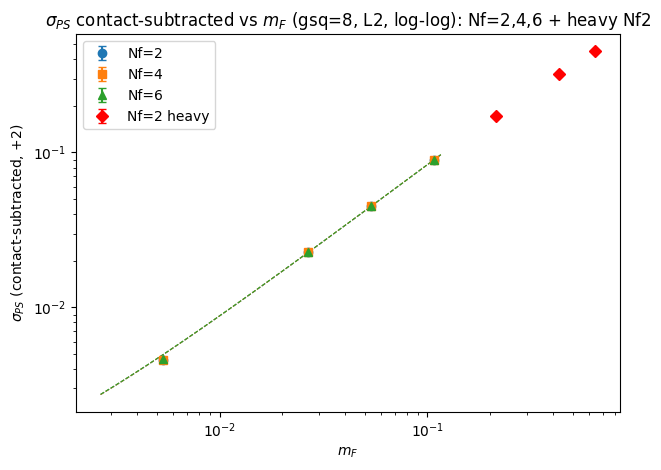

In [5]:
# Contact-subtracted sigma_PS vs m_F, LOG-LOG: light Family-B (Nf=2,4,6) + heavy (Nf=2, red diamond).
# Light now on the SAME L2 effective-m_F convention as heavy (cell 1).  Log-log makes the linear
# (slope-1) approach sigma_PS ~ chi*m -> 0 visible as a straight line.  Light linear chiral fit
# (intercept = chiral limit) printed before the plot.
for nf in NFS:
    rm, re, sm, se = SIG[nf]
    slope, icpt = np.polyfit(MASS, sm, 1)
    print(f'Nf={nf}: contact-sub sigma_PS = {slope:+.4f}*m_F + ({icpt:+.5f})   [linear fit; intercept = m->0 condensate]')

fig, ax = plt.subplots()
mg = np.logspace(np.log10(MASS.min()*0.5), np.log10(MASS.max()*1.1), 200)
for i, nf in enumerate(NFS):
    rm, re, sm, se = SIG[nf]
    slope, icpt = np.polyfit(MASS, sm, 1)
    ax.errorbar(MASS, sm, yerr=se, marker=NFMARK[i], ls='none', capsize=3, label=f'Nf={nf}')
    ax.plot(mg, slope*mg + icpt, ls='--', lw=0.8, color=ax.lines[-1].get_color())
hmf, hrm, hre, hsm, hse = HEAVY
if len(hmf):
    ax.errorbar(hmf, hsm, yerr=hse, marker='D', color='red', ls='none', capsize=3, label='Nf=2 heavy')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_F$'); ax.set_ylabel(r'$\sigma_{PS}$ (contact-subtracted, $+2$)')
ax.set_title(r'$\sigma_{PS}$ contact-subtracted vs $m_F$ (gsq=8, L2, log-log): Nf=2,4,6 + heavy Nf2')
ax.legend(); plt.tight_layout()


In [ ]:
# Contact-subtracted sigma_FS vs m_F, LOG-LOG (heavy Nf2, red diamond).  sigma_FS is uniformly
# NEGATIVE here, so we plot -sigma_FS on log-y.  Order param = sigma_FS/V_st + (2 - m_F).
fig, ax = plt.subplots()
hmf_fs, hfs_rm, hfs_re, hfs_sm, hfs_se = HEAVY_FS
if len(hmf_fs):
    ax.errorbar(hmf_fs, -hfs_sm, yerr=hfs_se, marker='D', color='red', ls='none', capsize=3, label='Nf=2 heavy')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$m_F$')
ax.set_ylabel(r'$-\sigma_{FS}$ (contact-subtracted, $+2-m_F$)')
ax.set_title(r'$-\sigma_{FS}$ contact-subtracted vs $m_F$ (gsq=8, L2, log-log): heavy Nf2')
ax.legend()
plt.tight_layout()

In [7]:
# # Raw sigma_PS vs m_F, Nf=2,4,6 (before the +2 contact subtraction).
# fig, ax = plt.subplots()
# for i, nf in enumerate(NFS):
#     rm, re, sm, se = SIG[nf]
#     ax.errorbar(MASS, rm, yerr=re, marker=NFMARK[i], ls='none', capsize=3, label=f'Nf={nf}')
# ax.axhline(-2.0, color='k', lw=0.5, ls=':')
# ax.set_xlabel(r'$m_F$'); ax.set_ylabel(r'$\sigma_{PS}$ (raw)')
# ax.set_title(r'$\sigma_{PS}$ raw vs $m_F$ (gsq=8): Nf=2,4,6  (contact term $\approx-2$)')
# ax.legend(); plt.tight_layout()
